In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

# Carrega a base principal já tratada para análise
csv_path = Path(r"C:\Users\mateu\OneDrive\Documentos\SPTECH\TCC\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv")
df = pd.read_csv(csv_path, index_col=0, delimiter=",")

# Visualização inicial para validar estrutura e tipos
df.head()

,order_delivered_customer_date,holiday_at_shipping,approval_time_hours,handling_time_hours,shipping_delay_hours,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,...,customer_meso_sao_jose_do_rio_preto,customer_meso_macro_metropolitana_paulista,customer_meso_bauru,customer_meso_araraquara,customer_meso_presidente_prudente,customer_meso_marilia,customer_meso_assis,customer_meso_aracatuba,customer_meso_itapetininga,customer_meso_litoral_sul_paulista
order_delivered_carrier_date,,,,,,,,,,,,,,,,,,,,,
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-02-09T10:54:50.000Z,2017-02-15T15:41:51.000Z,0,73.354,55.075,32.430,11.551,2,6,1,239.00,...,0,1,0,0,0,0,0,0,0,0


In [2]:
# Seleciona apenas colunas numéricas (base do PCA)
df_numeric = df.select_dtypes(include=[np.number]).copy()

# Remover colunas conforme solicitado (clima e vazamento de dados)
colunas_remover = [
    # Vazamento de dados / Pós-compra (ocorrem após aprovação ou derivam do tempo de entrega)
    'order_delivered_customer_date', 
    'order_delivered_carrier_date',
    'review_score', 
    # 'delivered_on_time', # Vamos manter esta no df principal apenas para análises descritivas, não passaremos ela para 'X'.
    'approval_time_hours', 
    'handling_time_hours', 
    'shipping_delay_hours',
    
    # Variáveis climáticas (Vendedor)
    'seller_total_rainfall_period_mm',
    'seller_max_rain_intensity_mm_h',
    'seller_max_wind_gust_period_ms',
    'seller_interval_code',
    'seller_rain_class_code',
    'seller_wind_class_code',
    'seller_accumulated_rainfall_3_days_mm',
    'seller_is_heavy_rain',
    'seller_is_strong_wind',
    
    # Variáveis climáticas (Cliente)
    'customer_total_rainfall_period_mm',
    'customer_max_rain_intensity_mm_h',
    'customer_max_wind_gust_period_ms',
    'customer_interval_code',
    'customer_rain_class_code',
    'customer_wind_class_code',
    'customer_accumulated_rainfall_3_days_mm',
    'customer_is_heavy_rain',
    'customer_is_strong_wind',

    'seller_meso_metropolitana_de_sao_paulo',
    'seller_meso_araraquara',
    'seller_meso_piracicaba',
    'seller_meso_ribeirao_preto',
    'seller_meso_sao_jose_do_rio_preto',
    'seller_meso_campinas',
    'seller_meso_vale_do_paraiba_paulista',
    'seller_meso_macro_metropolitana_paulista',
    'seller_meso_bauru',
    'seller_meso_presidente_prudente',
    'seller_meso_marilia',
    'seller_meso_assis',
    'seller_meso_aracatuba',
    'seller_meso_litoral_sul_paulista',
    'seller_meso_itapetininga',
    'customer_meso_metropolitana_de_sao_paulo',
    'customer_meso_piracicaba',
    'customer_meso_campinas',
    'customer_meso_vale_do_paraiba_paulista',
    'customer_meso_ribeirao_preto',
    'customer_meso_sao_jose_do_rio_preto',
    'customer_meso_macro_metropolitana_paulista',
    'customer_meso_bauru','customer_meso_araraquara',
    'customer_meso_presidente_prudente',
    'customer_meso_marilia',
    'customer_meso_assis',
    'customer_meso_aracatuba',
    'customer_meso_itapetininga',
    'customer_meso_litoral_sul_paulista'
]
df_numeric = df_numeric.drop(columns=colunas_remover, errors='ignore')

# Remove linhas com ausentes para evitar distorções no escalonamento/PCA
df_numeric = df_numeric.dropna()

# Auto-escalando os dados (StandardScaler)
from sklearn.preprocessing import StandardScaler
scale_obj = StandardScaler()
df_scaled = pd.DataFrame(scale_obj.fit_transform(df_numeric), columns=df_numeric.columns)

print(f"Colunas usadas no PCA: {len(df_numeric.columns)}")
df_scaled.head()

Colunas usadas no PCA: 17


,holiday_at_shipping,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,delivered_on_time,seller_geolocation_lat,seller_geolocation_lng,customer_geolocation_lat,customer_geolocation_lng,month
0,-0.029295,-0.309499,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,-0.076682,-0.405858,0.253228,-0.577763,0.587704,-0.858066,-1.049984,-1.596289
1,-0.029295,-0.309499,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,-0.076682,-0.405858,0.253228,-0.577763,0.587704,-0.858066,-1.049984,-1.596289
2,-0.029295,-0.309499,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,-0.076682,-0.405858,0.253228,-0.577763,0.587704,-0.858066,-1.049984,-1.596289
3,-0.029295,-0.309499,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,-0.076682,-0.405858,0.253228,-0.577763,0.587704,-0.858066,-1.049984,-1.596289
4,-0.029295,0.609801,-2.385801,1.652522,1.762488,1.197198,0.060855,-0.413212,-0.595630,-0.475661,-0.405858,0.253228,0.296962,-0.340633,-0.858066,-1.049984,-1.280988


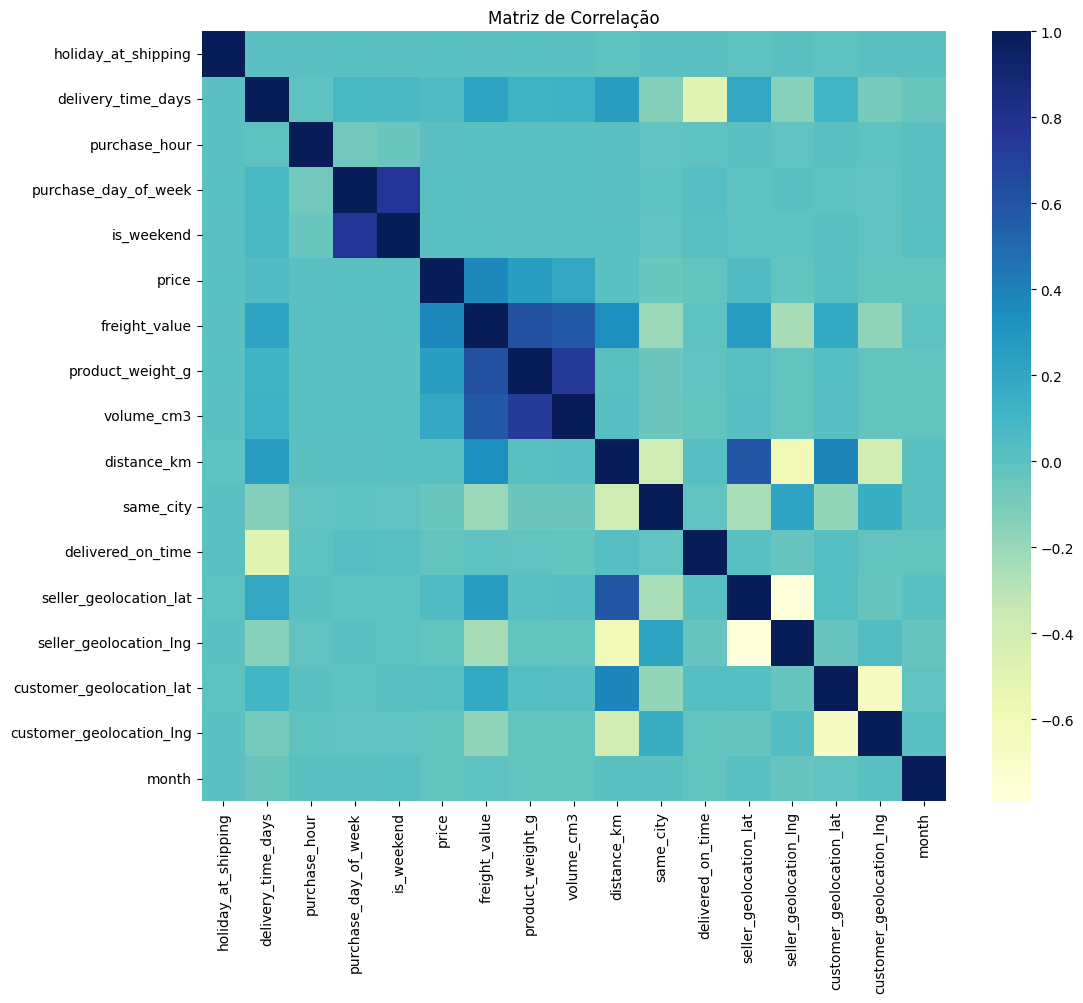

In [3]:
# Calculando a matriz de correlações
corr = df_scaled.corr()

# Heatmap da matriz de correlações
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="YlGnBu", annot=False)
plt.title("Matriz de Correlação")
plt.show()

In [4]:
from sklearn.decomposition import PCA

X = df_scaled.values
y = df["review_score"].values  

# Usa até 10 componentes, limitado ao número de variáveis disponíveis
n_components = min(10, X.shape[1])
pca = PCA(n_components=n_components)
pca.fit(X)

print("Variância explicada por cada componente:")
print(np.round(pca.explained_variance_ratio_, 3))

print("\nVariância acumulada:")
print(np.round(pca.explained_variance_ratio_.cumsum(), 3))

Variância explicada por cada componente:
[0.185 0.129 0.105 0.097 0.084 0.059 0.059 0.058 0.053 0.049]

Variância acumulada:
[0.185 0.313 0.418 0.515 0.599 0.658 0.717 0.775 0.828 0.877]


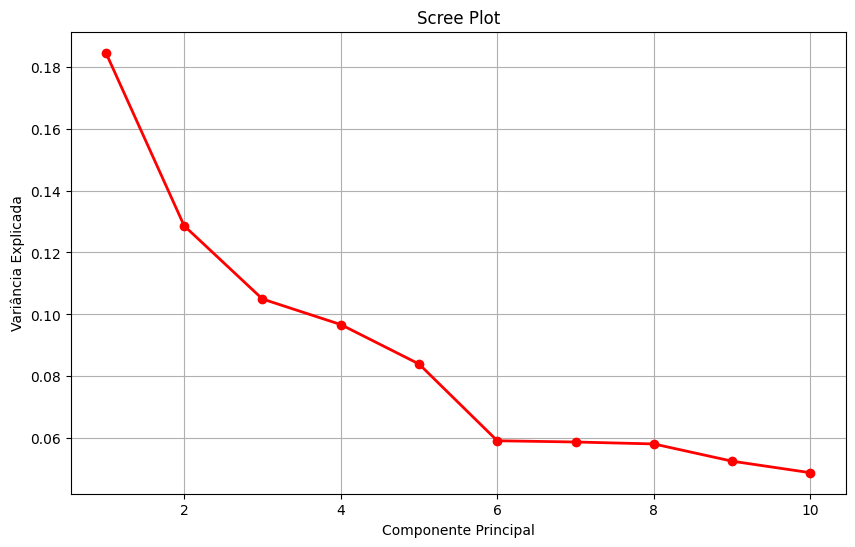

In [5]:
# Scree Plot
fig = plt.figure(figsize=(10, 6))

plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel("Componente Principal")
plt.ylabel('Variância Explicada')

plt.grid(True)
plt.show()

In [6]:
# Define o limiar mínimo de variância explicada acumulada
target_cumulative_variance = 0.80

# Ajusta um PCA completo para descobrir quantos componentes são necessários
pca_all = PCA()
pca_all.fit(X)
cumulative_variance = pca_all.explained_variance_ratio_.cumsum()

# Seleciona automaticamente o menor número de componentes que atinge o limiar
n_components_final = np.argmax(cumulative_variance >= target_cumulative_variance) + 1
pca_final = PCA(n_components=n_components_final)

# Calcula os scores uma única vez para evitar reprocessamento
scores = pca_final.fit_transform(X)

# Nomeia dinamicamente os componentes gerados
df_pca = df_numeric.copy()
for i in range(n_components_final):
    df_pca[f'PCA{i+1}'] = scores[:, i]

print(f"Componentes selecionados: {n_components_final}")
print(f"Variância acumulada atingida: {cumulative_variance[n_components_final - 1]:.3f}")

# Exibe os maiores scores no primeiro componente
df_pca.sort_values(by='PCA1', ascending=False).head(10)

Componentes selecionados: 9
Variância acumulada atingida: 0.828


,holiday_at_shipping,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,distance_km,...,month,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9
order_delivered_carrier_date,,,,,,,,,,,,,,,,,,,,,
2017-12-04T19:48:46.000Z,0,173.133,15,3,0,73.80,12.02,100,816.0,374.310,...,12,7.983855,-1.490632,3.000115,-4.476047,-19.465468,0.376746,0.326924,-0.281911,-0.672307
2018-02-27T21:04:40.000Z,0,10.530,10,6,1,258.99,32.84,20950,154980.0,191.168,...,2,7.676518,8.859458,1.574644,-0.834098,2.096835,-0.991640,-0.229055,-0.410556,-2.874751
2017-12-12T21:37:05.000Z,0,7.971,19,1,0,1009.00,22.69,15800,134292.0,542.927,...,12,7.611806,7.391496,-1.659596,4.000001,1.461136,1.649362,1.348927,0.204189,3.650828
2017-06-05T13:00:41.000Z,0,145.121,17,6,1,179.00,12.75,460,5600.0,345.012,...,6,7.462320,-0.830591,5.344543,0.631016,-16.623039,-0.368080,-0.789205,0.478358,0.077831
2017-05-04T14:35:00.000Z,0,16.216,10,3,0,239.90,19.93,30000,60000.0,588.028,...,5,7.330528,6.008552,-0.590787,4.569315,0.398632,-0.372260,0.514827,-0.862161,-2.207678
2018-02-21T16:26:52.000Z,0,39.652,20,3,0,179.99,32.29,10700,64000.0,428.310,...,2,7.286423,3.212812,-0.513557,-2.457982,-1.678185,-0.667309,-1.133343,0.937469,-1.241438
2017-11-30T19:56:45.000Z,0,39.645,1,2,0,159.99,32.15,10700,64000.0,414.935,...,11,7.272869,3.328022,-0.306955,-3.108619,-4.695864,0.028183,1.971906,-2.603291,-0.994977
2018-02-28T01:27:04.000Z,0,14.130,12,4,0,159.99,32.15,10700,64000.0,261.286,...,2,7.212664,2.571714,-0.347347,1.492546,0.855228,-0.981549,-0.420377,-0.403876,-1.209381
2017-12-16T16:33:14.000Z,0,32.179,17,5,1,139.99,32.01,10700,64000.0,421.636,...,12,7.147340,3.285141,1.973138,-2.978487,-3.652468,1.576181,1.463705,0.279976,-1.034820


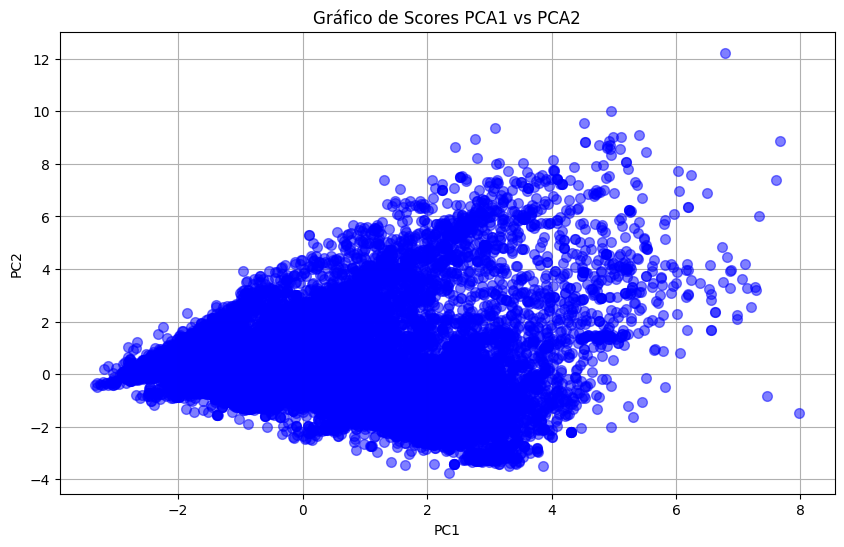

In [7]:
import matplotlib.pyplot as plt

# Gráfico de Scores (PCA1 x PCA2)
marker_style = dict(linestyle='none', marker='o', markersize=7, color='blue', alpha=0.5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(scores[:, 0], scores[:, 1], label="Scores", **marker_style)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Gráfico de Scores PCA1 vs PCA2")
ax.grid(True)

plt.show()

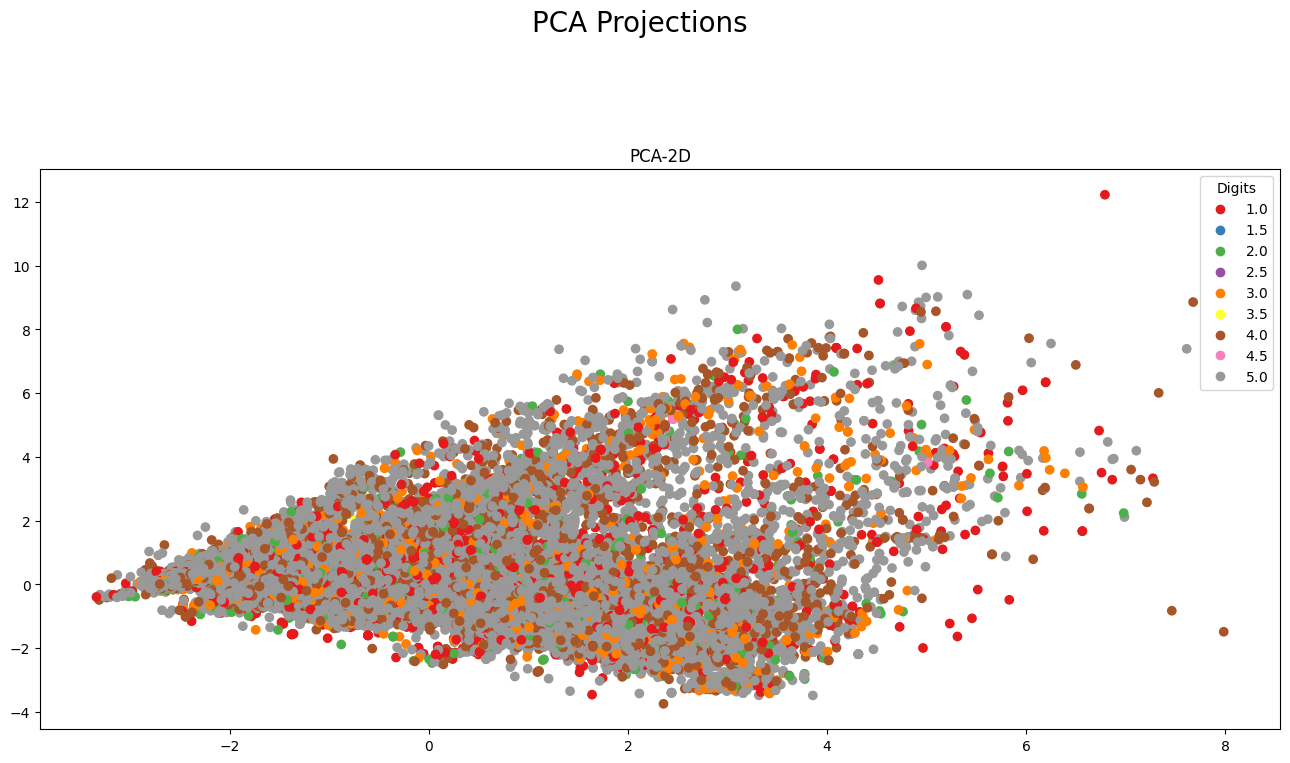

In [8]:
pca2d = PCA(n_components=2)
X_pca_2d = pca2d.fit_transform(X)


pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.colors

fig = plt.figure(figsize=(16, 16))
fig.suptitle('PCA Projections', fontsize=20)

# Plot the 2D projection
ax1 = fig.add_subplot(211)
ax1.title.set_text('PCA-2D')
scatter1 = ax1.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='Set1')
legend1 = ax1.legend(*scatter1.legend_elements(), title='Digits')

# Create an interactive 3D plot using plotly
colorscale = plotly.colors.qualitative.Set1
fig3d = go.Figure(data=[go.Scatter3d(x=X_pca_3d[:, 0], y=X_pca_3d[:, 1], z=X_pca_3d[:, 2],
                                    mode='markers', marker=dict(color=y, colorscale=colorscale),
                                    text=y, hovertemplate='%{text}')])
fig3d.update_layout(title='PCA-3D', width=800, height=800)
fig3d.show()

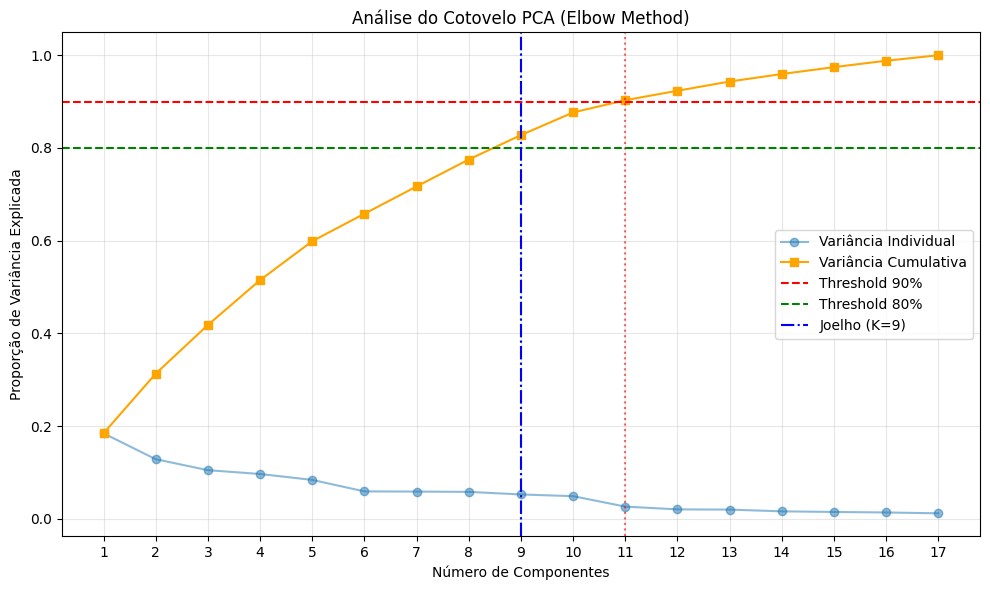

Componentes necessários para 80% da variância: 9
Componentes necessários para 90% da variância: 11
Ponto de joelho sugerido matematicamente: 9


In [9]:
# PCA elbow: variance explained by each component
from kneed import KneeLocator

pca_elbow = PCA().fit(df_scaled)
explained = pca_elbow.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Identificação automática do "cotovelo" usando a biblioteca kneed
# kneedle_explained = KneeLocator(range(1, len(explained) + 1), explained, S=1.0, curve='convex', direction='decreasing')
kneedle_cumulative = KneeLocator(range(1, len(cumulative) + 1), cumulative, S=1.0, curve='concave', direction='increasing')

n_90 = np.searchsorted(cumulative, 0.90) + 1
n_80 = np.searchsorted(cumulative, 0.80) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained) + 1), explained, marker='o', label='Variância Individual', alpha=0.5)
plt.plot(range(1, len(cumulative) + 1), cumulative, marker='s', label='Variância Cumulativa', color='orange')

# Linhas de referência para 80% e 90%
plt.axhline(y=0.90, color='r', linestyle='--', label='Threshold 90%')
plt.axvline(x=n_90, color='r', linestyle=':', alpha=0.6)
plt.axhline(y=0.80, color='g', linestyle='--', label='Threshold 80%')
plt.axvline(x=n_80, color='g', linestyle=':', alpha=0.6)

if kneedle_cumulative.knee:
    plt.axvline(x=kneedle_cumulative.knee, color='blue', linestyle='-.', label=f'Joelho (K={kneedle_cumulative.knee})')

plt.xlabel('Número de Componentes')
plt.ylabel('Proporção de Variância Explicada')
plt.title('Análise do Cotovelo PCA (Elbow Method)')
plt.xticks(range(1, len(explained) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Componentes necessários para 80% da variância: {n_80}")
print(f"Componentes necessários para 90% da variância: {n_90}")
if kneedle_cumulative.knee:
    print(f"Ponto de joelho sugerido matematicamente: {kneedle_cumulative.knee}")
else:
    print("Não foi possível detectar um ponto de joelho claro (curva muito linear).")

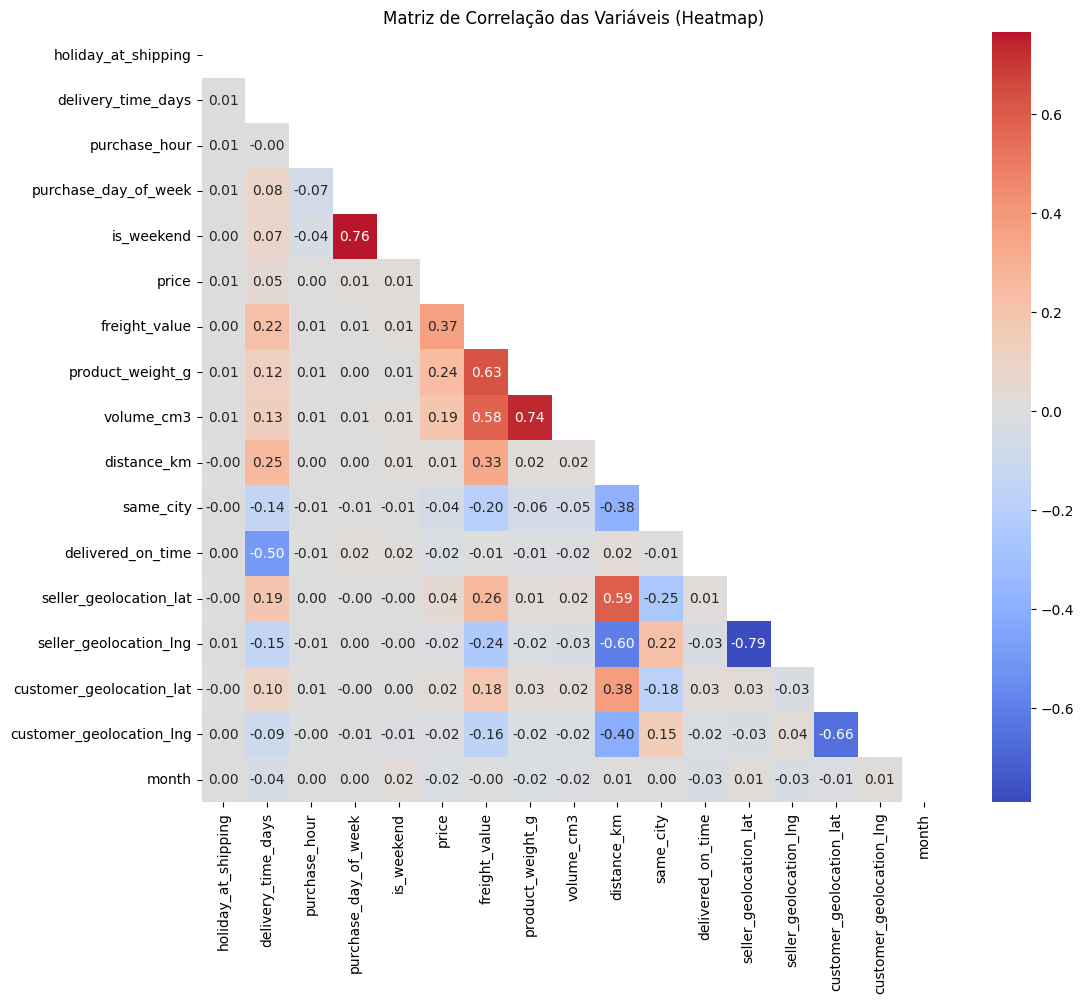

Nenhuma par de variáveis com correlação extrema (>0.8) detectado.


In [10]:
# Matriz de Correlação das Features
import seaborn as sns

plt.figure(figsize=(12, 10))
# Usando o df_scaled (numeric) para correlação
corr_matrix = df_scaled.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlação das Variáveis (Heatmap)')
plt.show()

# Listar pares com alta correlação (> 0.8) que influenciam na "linearidade" do PCA
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    print("Pares de variáveis com alta correlação (>0.8):")
    for var1, var2, val in high_corr:
        print(f"- {var1} & {var2}: {val:.2f}")
else:
    print("Nenhuma par de variáveis com correlação extrema (>0.8) detectado.")

## Modelagem Matemática do PCA

O PCA (*Principal Component Analysis*) é uma técnica estatística utilizada para redução de dimensionalidade, transformando variáveis originais possivelmente correlacionadas em novas variáveis chamadas **Componentes Principais**.

### 1. Padronização dos Dados

Inicialmente, os dados são padronizados para que todas as variáveis fiquem na mesma escala, com média zero e desvio padrão igual a 1.

$$
z = \frac{x - \mu}{\sigma}
$$

Onde:

- $x$ = valor original  
- $\mu$ = média da variável  
- $\sigma$ = desvio padrão

---

### 2. Matriz de Covariância

Após a padronização, calcula-se a matriz de covariância, responsável por medir a relação entre as variáveis.

$$
Cov(X,Y)=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1}
$$

Essa etapa permite identificar quais variáveis variam juntas.

---

### 3. Cálculo dos Autovalores e Autovetores

Em seguida, o PCA resolve a equação:

$$
A\vec{v} = \lambda \vec{v}
$$

Onde:

- $A$ = matriz de covariância  
- $\lambda$ = autovalor  
- $\vec{v}$ = autovetor

Os **autovetores** indicam as direções dos novos eixos principais, enquanto os **autovalores** representam a quantidade de variância explicada por cada componente.

---

### 4. Formação dos Componentes Principais

Cada componente principal é formado por uma combinação linear das variáveis originais:

$$
PC_1 = a_1X_1 + a_2X_2 + ... + a_nX_n
$$

Onde:

- $X_1, X_2, ..., X_n$ = variáveis originais  
- $a_1, a_2, ..., a_n$ = pesos definidos pelos autovetores

---

### 5. Objetivo Final

O objetivo do PCA é reduzir o número de dimensões do conjunto de dados, preservando a maior quantidade possível de informação (variância), facilitando análises, visualizações e modelagens futuras.